#Jupyter notebook to test LWR library

This code uses the code made by Randall J. LeVeque to model traffic flow and "shock waves" for modelling traffic lights and traffic jams. This only works in jupyter notebook.

In [19]:
import sys
import os
%matplotlib inline

# Add the riemann_book folder to Python's path
sys.path.append(os.path.join(os.getcwd(), 'riemann_book'))

import matplotlib as mpl
mpl.rcParams['font.size'] = 8
figsize =(8,4)
mpl.rcParams['figure.figsize'] = figsize

import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from ipywidgets import widgets, FloatSlider

from utils import riemann_tools
from exact_solvers import traffic_LWR

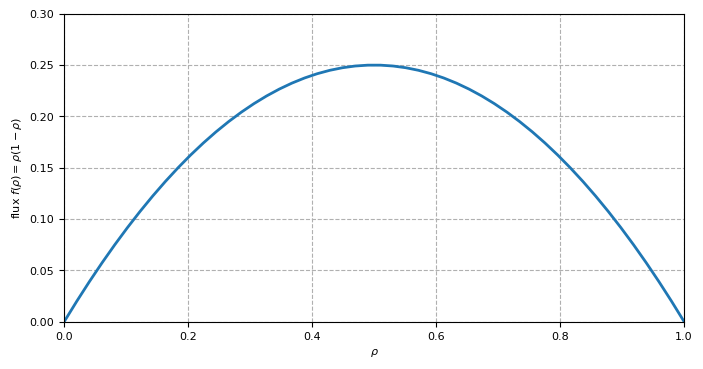

In [20]:
rho = np.linspace(0,1)
f = rho*(1.-rho)
plt.plot(rho,f,linewidth=2)
plt.xlabel(r'$\rho$'); plt.ylabel(r'flux $f(\rho) = \rho(1-\rho)$');
plt.ylim(0,0.3); plt.xlim(0,1); plt.grid(linestyle='--');

In [21]:
def jam(rho_l=0.4,t=0.1):
    shock_speed = -rho_l
    shock_location = t*shock_speed
    fig, axes = plt.subplots(1,2,figsize=figsize)
    
    axes[0].plot([-1,shock_location],[rho_l,rho_l],'k',lw=2)
    axes[0].plot([shock_location,shock_location],[rho_l,1.],'k',lw=2)
    axes[0].plot([shock_location,1.],[1.,1.],'k',lw=2)
    axes[0].set_xlabel('$x$'); axes[0].set_ylabel(r'$\rho$'); 
    axes[0].set_xlim(-0.2,0.2); axes[0].set_ylim(0,1.1)
    traffic_LWR.plot_car_trajectories(rho_l,1.,axes[1]); 
    axes[1].set_ylim(0,1); axes[0].set_title(r'$t= $'+str(t))
    plt.xlabel('$x$'); plt.ylabel(r'$t$');
    plt.show()
    
interact(jam,
         rho_l=FloatSlider(min=0.,max=0.9,value=0.2,description=r'$\rho_l$'),
         t=FloatSlider(min=0.,max=1.,value=0.2));


interactive(children=(FloatSlider(value=0.2, description='$\\rho_l$', max=0.9), FloatSlider(value=0.2, descrip…